In [1]:
from huggingface_hub import InferenceClient
from pydantic import BaseModel
from typing import Literal
import json
from tqdm import tqdm
import jsonlines

class Response(BaseModel):
    reasoning: str
    answer: Literal['Style', 'Naming', 'Questioning', 'Response', 'Convention', 
                    'Testing', 'Design', 'Refactoring', 'Functionality', 
                    'Roadmap', 'Optimization', 'Error', 'Documentation', 
                    'Support', 'InputOutput', 'Other']

class GroupResponse(BaseModel):
    reasoning: str
    target_group: Literal['CodeStyle', 'Development', 'Discussion', 'User', 'Other']
    target_subtype:  Literal['Style', 'Naming', 'Questioning', 'Response', 'Convention', 
                                               'Testing', 'Design', 'Refactoring', 'Functionality', 
                                               'Roadmap', 'Optimization', 'Error', 'Documentation', 
                                               'Support', 'InputOutput', 'Other']

class FlatTaxonomyResponse(BaseModel):
    reasoning: str
    target_subtype:  Literal['Style', 'Questioning', 'Response', 
                                               'Testing', 'Design', 'Refactoring', 'Functionality', 
                                               'Process', 'Optimization', 'Error', 'Documentation', 
                                               'Other']

/home/xmagpie/.virtualenvs/comment-simplification/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [90]:
flat_taxonomy = [
    'Style', 'Questioning', 'Response',  'Testing', 'Design', 'Refactoring', 'Functionality',  
    'Process', 'Optimization', 'Error', 'Documentation',  'Other'
]

In [93]:
path = "/dump/crc_dataset/crc_test1803.jsonl"
messages = []
with open(path, 'r') as f:
    for item in jsonlines.Reader(f):
        message = item.get("message")
        group = item.get("group")
        label = item.get("label")
        if label in ('Roadmap', 'Convention', 'Support'):
            label = 'Process'

        if label == 'Naming':
            label = 'Style'

        if label == 'InputOutput':
            label = 'Functionality'
        
        if message is not None and label is not None and group is not None:
            messages.append({'message': message, 'group': group, 'label': label})

In [3]:
len(messages)

2207

In [4]:
prompt = """
Classify the comment: {comment} to one of the existing classes.

1. Style -- readability, code layout, indentation issues, and other common programming conventions
2. Naming -- uniform style and convenience of naming variables, methods, classes
3. Questioning -- questions to the author of the code, requests clarification of the code or examples of use
4. Response -- appointment of other reviewers, writes acknowledgements, agreements with others, additions to the developer's opinion
5. Convention -- discussion of the software development process
6. Testing -- requests tests to verify the functionality of the code
7. Design -- architecture and code design, program structure control
8. Refactoring -- logical structure, object creation, logical errors
9. Functionality -- identification of code defects
10. Roadmap -- further development of the program
11. Optimization -- code optimization, suggestions for parallelization etc.
12. Error -- dentifies problems with exception and error handling
13. Documentation -- problems with documentation or comments in the source code
14. Support -- compatibility with other systems, support systems
15. Input/Output -- input/output in the graphical user interface, problems with pop-up windows.
16. Other -- comments that do not carry a semantic load without proper context
"""


system_prompt = f"""
You are an expert code reviewer with a great experience in review comment classificaiton. Your job is to classify the given comments into one of the existing classes.

If the comment is too complex and can be classified into multiple target classes, try to pick single class which better emphasizes the overall semantics.

Below is a list of target classes with their short description.

1. Style -- readability, code layout, indentation issues, and other common programming conventions
2. Naming -- uniform style and convenience of naming variables, methods, classes
3. Questioning -- questions to the author of the code, requests clarification of the code or examples of use
4. Response -- appointment of other reviewers, writes acknowledgements, agreements with others, additions to the developer's opinion
5. Convention -- discussion of the software development process
6. Testing -- requests tests to verify the functionality of the code
7. Design -- architecture and code design, program structure control
8. Refactoring -- logical structure, object creation, logical errors
9. Functionality -- identification of code defects
10. Roadmap -- further development of the program
11. Optimization -- code optimization, suggestions for parallelization etc.
12. Error -- dentifies problems with exception and error handling
13. Documentation -- problems with documentation or comments in the source code
14. Support -- compatibility with other systems, support systems
15. Input/Output -- input/output in the graphical user interface, problems with pop-up windows
16. Other -- comments that do not carry a semantic load without proper context.

Please, respond in the following format: {Response.model_json_schema()}
"""

group_system_prompt = f"""
You are an expert code reviewer with a great experience in review comment classificaiton. Your job is to classify the given comments into one of the existing classes.

If the comment is too complex and can be classified into multiple target classes, try to pick single class which better emphasizes the overall semantics.

Below is a list of target classes with their short description.

1. CodeStyle -- related to naming, readability, code layout, indentation issues, and other common programming conventions
2. Development -- everything related to development, e.g. bugs, refactoring, design, optimization suggestions, error handling or documentation improvements. Comments that have only have specific source code suggestions  without any extra comments, fall in this category.
3. Discussion -- comments related to discussions, e.g. clarification questions to the author of the code or responses such as appointment of other reviewers, writes acknowledgements, agreements with others, additions to the developer's opinion.
4. User -- comments related to user and developer experience, e.g. documentation improvements, compatibility with other systems, support systems, input/output in the graphical user interface, problems with pop-up windows
5. Other -- comments that do not carry a semantic meaning without proper context.

Please, respond in the following format: {GroupResponse.model_json_schema()}
"""


In [5]:
guide_prompt = f"""

You are an expert code reviewer with a great experience in review comment classificaiton. Your job is to classify the given comments into one of the existing classes.  The main classes are Code Style, Discussion, Development, User and Other. Each one is described in detail below.

Please follow this guide prepared by some expert annotators, which also contains some QA pairs. The guide is hierarchical. Top level headings provide target classes, lower level headings describe sub-types of  comments in this class. 

Also note, that if a comment contains a question or response, that does not necessarily mean that it falls under Discussion category. If this question or response contains specific suggestions that can be mapped into Development, Code Style or User categories, do that.

## Code style
---
#### Style
Стиль программирования: удобочитаемость, компоновка кода, проблемы с отступами, и другие общие соглашения при написании исходного кода.

#### Naming
Единый стиль и удобство именования переменных, методов, классов, каждое имя несёт в себе смысл.

## Discussion
---
#### Questioning
Вопросы к автору кода. Просит разъяснение кода либо примеры использования.

#### Response
Назначает других рецензентов, пишет благодарности, соглашается с другими, дополняет мнения разработчика, устанавливает какое-либо решение

#### Convention
Обсуждение процесса разработки ПО.

#### Testing
Запрашивает тесты для проверки функционала кода.

## Development
---
#### Design
Архитектура и проектирование кода, контроль структуры программы.

#### Refactoring
Логическая структура, создание объектов, логические ошибки. Как правило отличаем от дизайна, если речь идет про стандартный рефакторинг (Fauler+паттерны проектирования) и language-specific идиомы (прим. pimpl и CRTP для C++)

#### Functionality
Правильно ли реализована задача, выявляет дефекты работы кода.

#### Roadmap
Как должна в дальнейшем развиваться программа.

#### Optimization
Оптимизация кода, параллелизм, синхронизация, отладка программы.

#### ErrorHandling
Выявляет проблемы обработки исключений и ошибок

## User
---
#### Documentation
Проблемы с документацией либо с комментариями в исходном коде.

#### Support
Совместимость с другими системами, системы поддержки.

#### Input/Output
Ввод/вывод в графическом интерфейсе пользователя, проблемы с всплывающими окнами.

## Other 
---
#### Other

Комментарии не несущие смысловой нагрузки без контекста same, same as above, see above, emojis, etc.

---
## SMA comments

-    Design vs Functionality ~ глобальное vs понятное локально (TODO). Roadmap ещё глобальней, больше одного спринта на задачу
-    Берём первую смысловую часть коммента
-    Type hints это CodeStyle/Style
-    Testing только про добавление/удаление тестов и логического изменении цели тестирования
-    Discussion/Questioning общий вопрос, который чаще всего можно задать почти к любому участку кода
-    Строковые константы это точно не CodeStyle/Naming
---
## KSO QA

- Каким классом мы хотим помечать комменты "We use pathlib instead os.path", "Use f-string instead of format" и тп когда предпочитают одно API или конструкции вместо других. Code style?

ОТВЕТ: Functional. Предлагают поменять апи, перейти на другой. Это стиль программирования, но не Code Style

- Как мы хотим помечать комменты в стиле done/corrected/fixed? response или other?

ОТВЕТ: Response

- Как мы хотим помечать комменты про необязательный код, типа "I wonder if this is needed since the TemporaryDirectory is deleted when garbage collected?"

ОТВЕТ: Что-то из Development, скорей всего  Functional or Design. В этом примере больше похоже на Optimization. Точно не про рефакторинг, так как обсуждается какая-то функциональность

- Как быть с комментами, когда человек соглашается с предложением и явно реитерирует/проговаривает, что он сделает? типа "Got you. I will remove this duplicate and introduce common function"

ОТВЕТ: Да тоже респонс, если там выше описано тоже самое, то зачем нам дублирование

- Как быть с комментами, когда человек обосновывает свой код, уже сделанное и это не response? что-то в духе "This is implemented in such way because ..."

ОТВЕТ: В категорию о чём он пишет. Design or Functionality  обычно

Here are also some examples:

1. "Could you explain why this is needed?" - Questioning  
2. "Looks good, I’ll remove the duplicate." - Response  
3. "Consider adding a test case for this condition." - Testing  
4. "Use f-strings instead of format for readability." - Style  
5. "Refactor this into a separate helper function." - Refactoring
6. "You're missing a try-catch block for this call." - ErrorHandling

"""

In [94]:
flat_taxonomy_prompt = """
You are a helpful assistant trained to classify code review comments based on their intent.  
Classify each comment into exactly one of the following categories:

Available Categories:

1. **Style** – Formatting, naming, code idioms, readability issues, or preferred constructs without affecting logic.  
   _Example_: “Use f-string instead of format”, “Rename `a` to `file_path` for clarity”

2. **Functionality** – Bug reports or behavior flaws, incorrect logic, missing features, or concerns about whether the code meets its purpose.  
   _Example_: “This doesn’t handle empty input”, “This method breaks when x is null”

3. **Design** – Architectural or structural suggestions: encapsulation, modularity, layering, cohesion/coupling, or inappropriate design decisions.  
   _Example_: “Move this into a separate service”, “Use a factory here instead of creating object inline”

4. **Optimization** – Performance, memory, parallelism, or efficiency issues.  
   _Example_: “This loop is inefficient, consider caching the results”, “Can we use a concurrent map here?”

5. **Error** – Missing exception handling or robustness checks, resilience to unexpected input.  
   _Example_: “This can throw if file doesn’t exist”, “You’re not checking the return code here”

6. **Refactoring** – Internal restructuring of code without changing behavior: cleanups, idiomatic rewrites, pattern application.  
   _Example_: “Extract this block into a separate function”, “This is a candidate for using a context manager”

7. **Testing** – Suggestions to add, modify, or remove tests.  
   _Example_: “Please add a test for edge case X”, “Remove this duplicate test”

8. **Questioning** – Requests for clarification, explanation, or rationale.  
   _Example_: “Why is this method needed?”, “Can you explain how this works?”

9. **Response** – Replies to reviewers, confirmations of intent, agreements, task acknowledgment.  
   _Example_: “Thanks, I’ll fix it”, “Done”, “I agree and will refactor”

10. **Process** – Comments about policies, conventions, roadmap, team workflows or release procedures.  
    _Example_: “Let’s do this in a separate PR”, “This is planned for the next sprint”

11. **Documentation** – Missing or unclear docstrings, inline comments, or user-facing docs.  
    _Example_: “Add docstring for this method”, “Please explain what this config does”

12. **Other** – Uninformative or vague comments, chit-chat, emojis, or "same"/"see above" without clear context.  
    _Example_: “👍”, “Same here”, “Lol”

---

Please, respond in the following format: {FlatTaxonomyResponse.model_json_schema()}
"""

In [100]:
client = InferenceClient(base_url="http://10.100.192.35:8083/v1")

result = []
failed_requests = []

user_prompt_template = 'Classify the following review comment:\n\n{comment}'

for comment in tqdm(messages[:500], desc="Processing comments", unit="comment"):
    request = user_prompt_template.format(comment=comment['message'])

    try:
        output = client.chat_completion(
            model="tgi",
            messages=[
                #{"role": "system", "content": group_system_prompt},
                {"role": "system", "content": flat_taxonomy_prompt},
                {"role": "user", "content": request},
            ],
            stream=False,
            max_tokens=256,
            temperature=0.0,
            response_format={
                "type": "json_object",
                "value": FlatTaxonomyResponse.model_json_schema()
            }
        )

        json_response = output.choices[0].message.content
        json_response = json.loads(json_response)
        result.append({**comment, **json_response})
        
    except Exception as e:
        print(f"Error processing comment: {comment}. Error: {e}")
        failed_requests.append({"comment": comment, "error": str(e)})

print("Processing complete!")

Processing comments: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [17:10<00:00,  2.06s/comment]

Processing complete!


In [109]:
from sklearn.metrics import f1_score

#f1_group = f1_score([r['group'] for r in result], [r['target_group'] for r in result], average='macro')
f1_subtype = f1_score([r['label'] for r in result], [r['target_subtype'] for r in result], average='macro')
#print(f'F1-score group {f1_group:.4f}\nF1-score type {f1_subtype:.4f}')
print(f'F1-score type {f1_subtype:.4f}')

F1-score type 0.4820


In [99]:
len(result)

200

In [41]:
wrong = [r for r in result if r['label'] != r['target_subtype']]

In [87]:
wrong[42]

{'message': 'can you do `unless model.is_a?(anonymous_module)`',
 'group': 'Development',
 'label': 'Functionality',
 'reasoning': "The comment is asking for clarification or explanation on why a specific condition is used in the code. It's not suggesting a change or pointing out an issue, but rather seeking understanding.",
 'target_subtype': 'Questioning'}

In [105]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [106]:
cm = confusion_matrix([r['label'] for r in result],  [r['target_subtype'] for r in result], labels=flat_taxonomy)
cm_relative = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_relative, display_labels=flat_taxonomy)

In [82]:
[r['label'] for r in result][6]

'User'

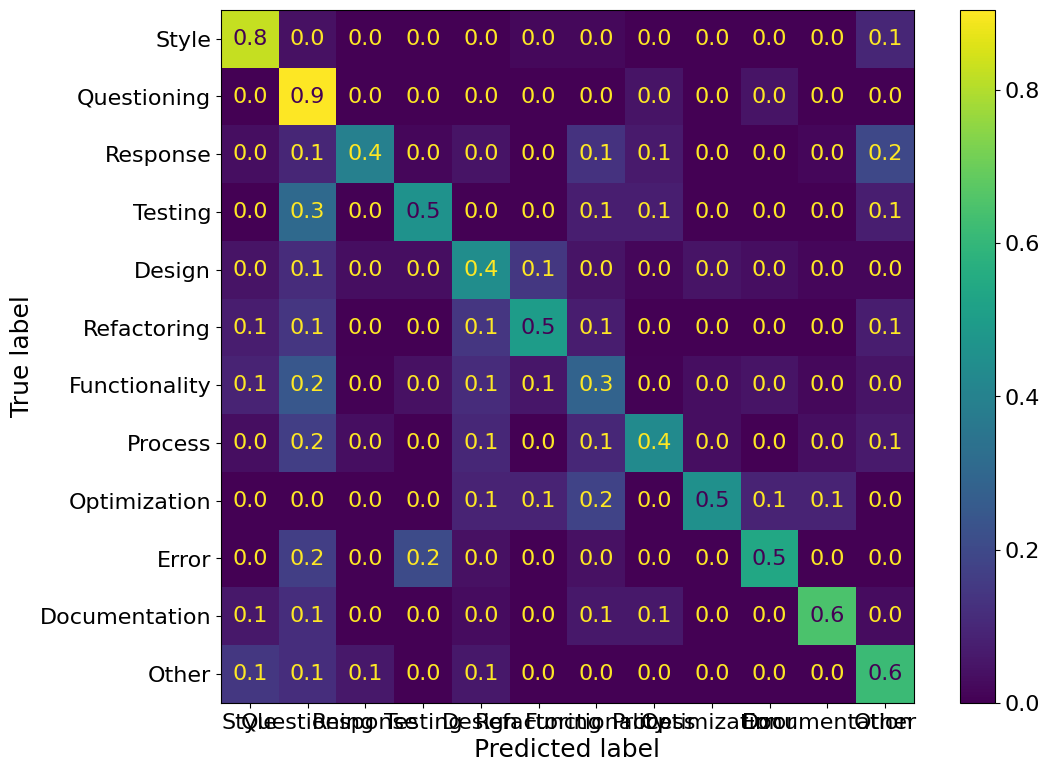

In [108]:
disp.plot(values_format=".1f")

In [86]:
from collections import Counter

In [87]:
Counter([r['label'] for r in result])

Counter({'Development': 3561,
         'Discussion': 1890,
         'User': 910,
         'CodeStyle': 850,
         'Other': 615})

In [96]:
wrong[-7]

{'message': 'Remove "On success, True is returned."',
 'label': 'User',
 'reasoning': 'The comment is suggesting a change to the documentation or comments within the code, specifically to remove a particular statement. This is related to improving the clarity and conciseness of the documentation, which falls under the category of Development.',
 'answer': 'Development'}

In [92]:
print('```suggestion\r\n    eps = 1e-7\r\n\r\n    _1m = 1.0 - eps\r\n    _1p = 1.0 + eps\r\n\r\n    _6_1m = 6.1 - eps\r\n    _6_1p = 6.1 + eps\r\n``')

```suggestion
    eps = 1e-7

    _1m = 1.0 - eps
    _1p = 1.0 + eps

    _6_1m = 6.1 - eps
    _6_1p = 6.1 + eps
``
